# 01 · EDA & Balance Checks

Understand the data, confirm the randomization produced comparable groups, and encode the categorical variables for the models that follow.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Locate the project root whether the notebook is run from notebooks/ or the repo root.
CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "src").exists() else CWD.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import data_prep as dp

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

## 1. Load the data and add the treatment flag

In [2]:
df = dp.load_raw()
df = dp.add_treatment_flag(df)
print(f"rows: {len(df):,}   columns: {df.shape[1]}")
df.head()

rows: 64,000   columns: 13


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend,treatment
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0,1
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0,0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0,1
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0,1
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0,1


Collapse the three-way `segment` column into a binary treatment: any email = 1, no email = 0.

In [3]:
pd.crosstab(df["segment"], df["treatment"])

treatment,0,1
segment,,
Mens E-Mail,0,21307
No E-Mail,21306,0
Womens E-Mail,0,21387


## 2. Data quality: missing values and types

In [4]:
missing = df.isna().sum()
print("missing values:", "none" if not missing.any() else "")
if missing.any():
    print(missing[missing > 0])
df.dtypes

missing values: none


recency              int64
history_segment        str
history            float64
mens                 int64
womens               int64
zip_code               str
newbie               int64
channel                str
segment                str
visit                int64
conversion           int64
spend              float64
treatment            int64
dtype: object

## 3. Outcome base rates

The three outcomes are `visit`, `conversion` (the **primary** outcome), and `spend`.

In [5]:
by_group = (df.groupby("treatment")[["visit", "conversion", "spend"]].mean().T)
by_group.columns = ["control (no email)", "treated (email)"]
by_group["overall"] = df[["visit", "conversion", "spend"]].mean().values
by_group.round(4)

,control (no email),treated (email),overall
visit,0.1062,0.1670,0.1468
conversion,0.0057,0.0107,0.0090
spend,0.6528,1.2496,1.0509


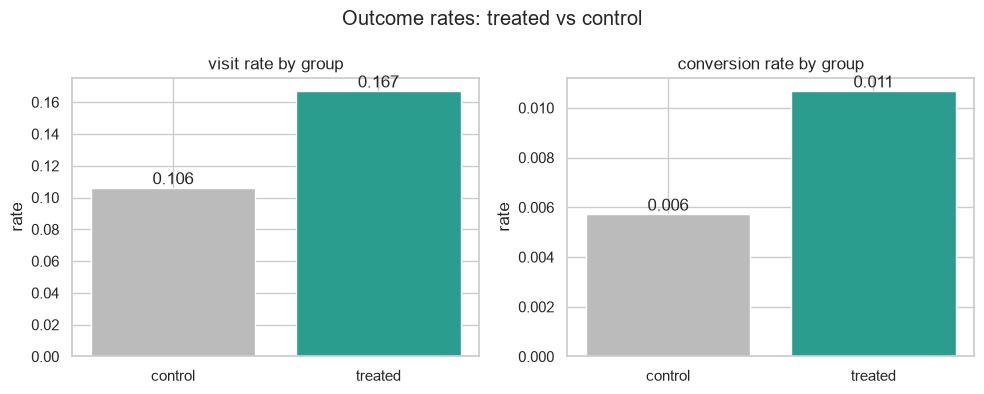

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric in zip(axes, ["visit", "conversion"]):
    means = df.groupby("treatment")[metric].mean()
    ax.bar(["control", "treated"], means.values, color=["#bbbbbb", "#2a9d8f"])
    ax.set_title(f"{metric} rate by group")
    ax.set_ylabel("rate")
    for i, v in enumerate(means.values):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom")
fig.suptitle("Outcome rates: treated vs control")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_outcome_rates_by_group.png", dpi=120, bbox_inches="tight")
plt.show()

`conversion` is a **rare event** (~0.9%) — small lifts with wide confidence intervals, and noisy per-customer uplift later.

share with zero spend: 0.9910


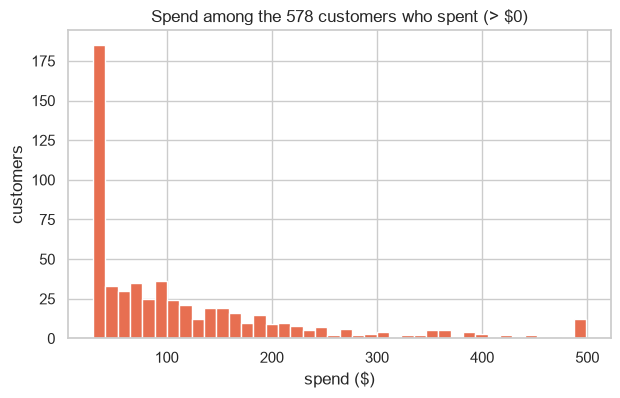

In [7]:
pct_zero = (df["spend"] == 0).mean()
print(f"share with zero spend: {pct_zero:.4f}")
pos = df.loc[df["spend"] > 0, "spend"]
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(pos, bins=40, color="#e76f51")
ax.set_title(f"Spend among the {len(pos):,} customers who spent (> $0)")
ax.set_xlabel("spend ($)"); ax.set_ylabel("customers")
fig.savefig(FIG_DIR / "01_spend_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

`spend` is **zero-inflated and right-skewed**: most customers spend $0, so Part A uses Welch's t-test.

## 4. Balance check — is this really randomized?

Measure the **standardized mean difference (SMD)** per covariate; |SMD| < 0.1 is well balanced.

In [8]:
bt = dp.balance_table(df)
bt.round(4)

,feature,smd,abs_smd,balanced
0,zip_code_Rural,0.0088,0.0088,True
1,history,0.0071,0.0071,True
2,mens,-0.0066,0.0066,True
3,zip_code_Surburban,-0.0064,0.0064,True
4,womens,0.0063,0.0063,True
5,recency,0.0060,0.0060,True
6,channel_Multichannel,-0.0047,0.0047,True
7,history_segment_ord,0.0030,0.0030,True
8,channel_Web,0.0029,0.0029,True
9,newbie,0.0008,0.0008,True


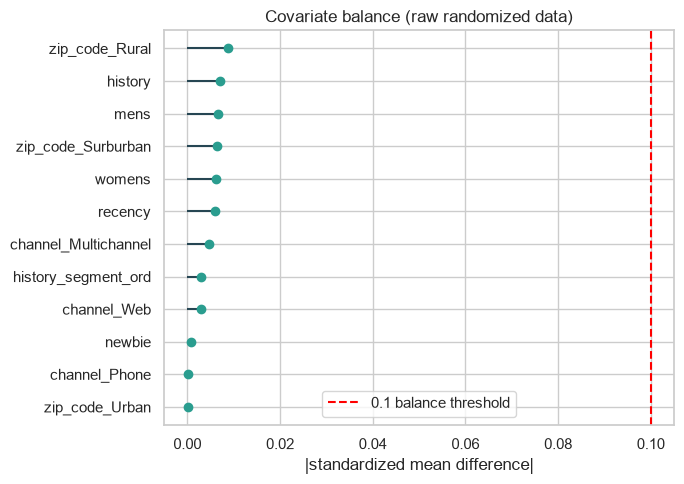

all covariates balanced (<0.1): True


In [9]:
order = bt.sort_values("abs_smd")
fig, ax = plt.subplots(figsize=(7, 5))
ax.hlines(y=order["feature"], xmin=0, xmax=order["abs_smd"], color="#264653")
ax.plot(order["abs_smd"], order["feature"], "o", color="#2a9d8f")
ax.axvline(0.1, color="red", ls="--", label="0.1 balance threshold")
ax.set_xlabel("|standardized mean difference|")
ax.set_title("Covariate balance (raw randomized data)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "01_balance_love_plot.png", dpi=120, bbox_inches="tight")
plt.show()
print("all covariates balanced (<0.1):", bool(bt["balanced"].all()))

Every SMD sits far below 0.1 — randomization held, so Part A's comparison estimates the true causal effect.

## 5. Feature relationships

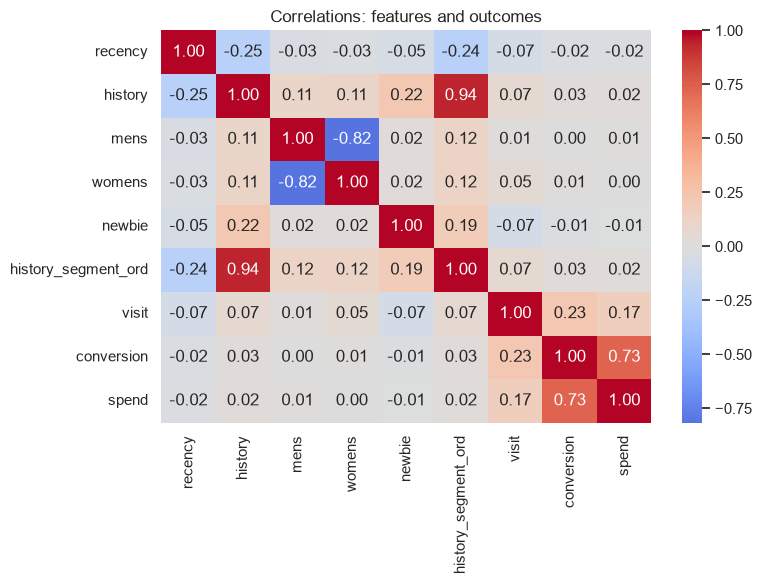

In [10]:
enc = dp.encode_features(df)
corr_cols = ["recency", "history", "mens", "womens", "newbie", "history_segment_ord"]
corr = pd.concat([enc[corr_cols], df[["visit", "conversion", "spend"]]], axis=1).corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlations: features and outcomes")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

`history` (past-year spend) is the feature most related to the outcomes — the natural lever for injecting selection bias in Part B.

## 6. Encode categoricals and save an analysis-ready table

In [11]:
enc = dp.encode_features(df)
print("encoded feature columns:")
print(list(enc.columns))

proc_path = PROJECT_ROOT / "data" / "processed" / "analysis.csv"
proc_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(proc_path, index=False)
print("\nsaved analysis table ->", proc_path.relative_to(PROJECT_ROOT))
enc.head()

encoded feature columns:
['recency', 'history', 'mens', 'womens', 'newbie', 'history_segment_ord', 'zip_code_Rural', 'zip_code_Surburban', 'zip_code_Urban', 'channel_Multichannel', 'channel_Phone', 'channel_Web']



saved analysis table -> data\processed\analysis.csv


,recency,history,mens,womens,newbie,history_segment_ord,zip_code_Rural,zip_code_Surburban,zip_code_Urban,channel_Multichannel,channel_Phone,channel_Web
0,10.0,142.44,1.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0,0.0
1,6.0,329.08,1.0,1.0,1.0,3.0,1.0,0.0,0.0,0.0,0.0,1.0
2,7.0,180.65,0.0,1.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0
3,9.0,675.83,1.0,0.0,1.0,5.0,1.0,0.0,0.0,0.0,0.0,1.0
4,2.0,45.34,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


## Takeaways From the Above Results

- 64,000 customers, no missing values.
- The experiment is genuinely randomized — every covariate SMD is well under 0.1.
- `conversion` is rare (~0.9%) and `spend` is zero-inflated.
- `history` is the strongest outcome-related feature, used to confound on in Part B.